In [26]:
import json
# check distribution of levels and subdomains through bar plots.
import matplotlib.pyplot as plt
from collections import Counter


In [27]:
with open('1-raw/native_mcqs.json', 'r') as f:
    data = json.load(f)

In [28]:
len(data)

9023

In [29]:
# find unique keys in the data
keys = set()
for item in data:
    keys.update(item.keys())
keys

{'correct_answer',
 'correct_index',
 'domain',
 'language',
 'level',
 'options',
 'options_english',
 'options_urdu',
 'question',
 'question_english',
 'question_number',
 'source',
 'std_domain',
 'std_subdomain',
 'subdomain',
 'url'}

In [30]:
# if a sample has any of the unique keys missing add the key with value ""
for item in data:
    for key in keys:
        if key not in item:
            item[key] = ""

In [31]:
# find if there are any sample which have a key missing from the unique keys
for item in data:
    for key in keys:
        if key not in item:
            print(item)

In [32]:
# find unique value of key domain
unique_domains = set()
for item in data:
    unique_domains.add(item['domain'])
unique_domains

{'Humanities',
 'Islamic Studies',
 'Law & Governance',
 'Professional',
 'Psychology & Education',
 'STEM',
 'Social Sciences'}

In [33]:
# find unique subdomains in the data
unique_sub_domains = set()
for item in data:
    unique_sub_domains.add(item['subdomain'])
len(unique_sub_domains)

65

In [36]:
# # use domain and source_image keys to find the level of the question, it could be 9th, 10th, SSC-I and SSC-II,
# # if one of these is found in 1 key store it on level key and do not look into other key, if none of these is found then level is ""
# for item in data:
#     if '9th' in item['domain'] or '9th' in item['source_image'] or '9th' in item['subdomain']:
#         item['level'] = '9th'
#     elif '10th' in item['domain'] or '10th' in item['source_image'] or '10th' in item['subdomain']:
#         item['level'] = '10th'
#     elif 'SSC-II' in item['domain'] or 'SSC-II' in item['source_image'] or 'SSC-II' in item['subdomain']:
#         item['level'] = 'SSC-II'
#     elif 'SSC-I' in item['domain'] or 'SSC-I' in item['source_image'] or 'SSC-I' in item['subdomain']:
#         item['level'] = 'SSC-I'
#     else:
#         item['level'] = ''

In [37]:
# # find samples where level is empty
# empty_level_samples = [item for item in data if item['level'] == '']
# len(empty_level_samples)

In [38]:
# # update level key as follow:
# # 9th-> SSC-I, 10th-> SSC-II, 11th-> HSSC-I, 12th-> HSSC-II
# level_mapping = {
#     '9th': 'SSC-I',
#     '10th': 'SSC-II',
#     '11th': 'HSSC-I',
#     '12th': 'HSSC-II'
# }
# levels = [item['level'] for item in data]
# mapped_levels = [level_mapping.get(level, level) for level in levels]
# mapped_level_counts = Counter(mapped_levels)
# # update the level key in data with mapped level
# for item in data:
#     item['level'] = level_mapping.get(item['level'], item['level'])

In [39]:
# # check distribution of levels and subdomains through bar plots.
# import matplotlib.pyplot as plt
# from collections import Counter

# levels = [item['level'] for item in data]
# level_counts = Counter(levels)

# plt.figure(figsize=(12, 5))
# plt.bar(level_counts.keys(), level_counts.values(), color='skyblue')
# plt.title('Distribution of Levels')
# plt.xlabel('Level')
# plt.ylabel('Count')
# plt.show()

In [40]:
data[0]

{'question_number': 1,
 'question': 'ہوا میں کونسی گیس ہوتی ہے؟',
 'options': {'A': 'نائٹروجن',
  'B': 'آکسیجن',
  'C': 'کاربن ڈائی آکسائیڈ',
  'D': 'ہائیڈروجن'},
 'correct_answer': 'A',
 'correct_index': 0,
 'subdomain': 'Everyday Science MCQs',
 'domain': 'STEM',
 'source': 'etest.com.pk',
 'level': '',
 'url': 'https://etest.com.pk/category/everyday-science-mcqs/',
 'language': 'ur',
 'std_domain': 'STEM',
 'std_subdomain': 'everyday_science',
 'question_english': '',
 'options_english': '',
 'options_urdu': ''}

In [13]:
subdomain_mapping = {
    'Advanced Islamic Studies (Elective) Paper-II': 'islamic studies',
    'Applied Electrician SSC-I': 'general science',
    'Arabic SSC-I': 'arabic',
    'Arabic SSC-II': 'arabic',
    'Art and Drawing SSC-I (برائے اطفال محروم سماعت و گویائی)': 'art and drawing',
    'Art and Model Drawing SSC-I': 'art and drawing',
    'Art and Model Drawing SSC-II': 'art and drawing',
    'Biology SSA-II': 'biology',
    'Biology SSC Part-II (10th Class)': 'biology',
    'Biology SSC-I': 'biology',
    'Biology SSC-II': 'biology',
    'Chemistry SSC Part-II (10th Class)': 'chemistry',
    'Chemistry SSC-I': 'chemistry',
    'Chemistry SSC-II': 'chemistry',
    'Civics SSC-I': 'civics',
    'Civics SSC-II': 'civics',
    'Civics/Pakistan Studies': 'civics',
    'Clothing and Textile SSC-I': 'economics',
    'Clothing and Textile SSC-II': 'economics',
    'Commercial Geography SSC-I': 'commerce',
    'Commercial Geography SSC-II': 'commerce',
    'Computer Science': 'computer science',
    'Computer Science SSC-I': 'computer science',
    'Computer Science SSC-II': 'computer science',
    'Dress Making SSC-I': 'home economics',
    'Dress Making and Fashion Designing SSC-I': 'home economics',
    'Dress Making and Fashion Designing SSC-II': 'home economics',
    'Economics': 'economics',
    'Economics SSC': 'economics',
    'Economics SSC Part-II (10th Class)': 'economics',
    'Economics SSC-I': 'economics',
    'Economics SSC-II': 'economics',
    'Education / Pedagogy': 'education',
    'Education SSC': 'education',
    'Education SSC Part-II (10th Class)': 'education',
    'Education SSC-I': 'education',
    'Education SSC-II': 'education',
    'Education/Child Development SSC': 'education',
    'Electrical Wiring SSC-I': 'general science',
    'Electrical Wiring SSC-II': 'general science',
    'Elements of Home Economics SSC-II': 'home economics',
    'English Compulsory SSC-I': 'english',
    'English Compulsory SSC-II': 'english',
    'English Elective / Literature SSC-II': 'english',
    'Essentials of Home Economics SSC-I': 'home economics',
    'Essentials of Home Economics SSC-II': 'home economics',
    'Ethics (For Non Muslim Candidates) SSC Part-II (10th Class)': 'ethics',
    'Ethics SSC-I': 'ethics',
    'Ethics SSC-II': 'ethics',
    'Fashion Designing SSC-I': 'home economics',
    'Food and Nutrition SSC-I': 'home economics',
    'Food and Nutrition SSC-II': 'home economics',
    'General Mathematics SSC Part-II (10th Class)': 'mathematics',
    'General Mathematics SSC-I': 'mathematics',
    'General Mathematics SSC-II': 'mathematics',
    'General Science / Geography': 'general science',
    'General Science / Geography SSA-II': 'general science',
    'General Science SSA-II': 'general science',
    'General Science SSC': 'general science',
    'General Science SSC Part-II (10th Class)': 'general science',
    'General Science SSC-I': 'general science',
    'General Science SSC-II': 'general science',
    'Geography SSC': 'geography',
    'Geography SSC-I': 'geography',
    'Geography SSC-II': 'geography',
    'Health and Physical Education SSC-I': 'health and physical education',
    'Health and Physical Education SSC-II': 'health and physical education',
    'History of Islam SSC-II': 'islamic studies',
    'History of Pakistan SSC-II': 'pakistan studies',
    'Home Economics': 'home economics',
    'Industrial Electrician SSC-I': 'general science',
    'Internet of Things Hardware Development SSC-I': 'computer science',
    'Internet of Things Software Development SSC-I': 'computer science',
    'Introduction to Tourism SSC-I': 'tourism management',
    'Islamiat': 'islamic studies',
    'Islamiat (Compulsory) SSC-II': 'islamic studies',
    'Islamiat SSC': 'islamic studies',
    'Islamiat SSC-I': 'islamic studies',
    'Islamiat SSC-II': 'islamic studies',
    'Islamic History SSC-I': 'islamic studies',
    'Islamic History SSC-II': 'islamic studies',
    'Islamic Studies SSC-I': 'islamic studies',
    'Islamic Studies SSC-II': 'islamic studies',
    'Islamiyat Compulsory SSC-I': 'islamic studies',
    'Islamiyat Compulsory SSC-II': 'islamic studies',
    'Islamiyat SSC-I': 'islamic studies',
    'Mathematics': 'mathematics',
    'Mathematics (Science Group) SSC Part-II (10th Class)': 'mathematics',
    'Mathematics (Science Group) SSC-II': 'mathematics',
    'Mathematics SSC': 'mathematics',
    'Mathematics SSC-I': 'mathematics',
    'Mathematics SSC-II': 'mathematics',
    'Media Production SSC-I': 'media production',
    'Motor Winding SSC-I': 'general science',
    'Pakistan Studies': 'pakistan studies',
    'Pakistan Studies SSC-I': 'pakistan studies',
    'Pakistan Studies SSC-II': 'pakistan studies',
    'Physics SSC Part-II (10th Class)': 'physics',
    'Physics SSC-I': 'physics',
    'Physics SSC-II': 'physics',
    'Plumbing and Solar Water Heating System-II SSC-I': 'plumbing',
    'Punjabi SSC-II': 'punjabi',
    'Science/General Science': 'general science',
    'Social Studies/Civics SSC-II': 'civics',
    'Tarjamatul Quran Ul Majeed Paper-II': 'tarjamatul quran',
    'Tarjamatul Quran Ul Majeed SSC-II': 'tarjamatul quran',
    'Tarjamatul Quran ul Majeed SSC-II': 'tarjamatul quran',
    'Tourism Management SSC-I': 'tourism management',
    'Urdu (Lazmi) SSC-I': 'urdu literature',
    'Urdu (Lazmi) SSC-II': 'urdu literature',
    'Urdu HSSC-I': 'urdu literature',
    'Urdu SSC-I': 'urdu literature',
    'Urdu SSC-II': 'urdu literature',
    'ریاضی ایس ایس سی I (Mathematics SSC-I)': 'mathematics',
    'علم التعليم SSC-I (Home Economics)': 'education',
    'علم التعلیم ایس ایس سی I': 'education',
    'علم التعلیم ایس ایس سی II': 'education',
    'مبادیات بوم اکنامکس ایس ایس سی (صنعت و کاریاری)': 'home economics',
    'مبادیات ہوم اکنامکس ایس ایس سی I': 'home economics',
    'مبادیات ہوم اکنامکس ایس ایس سی II': 'home economics',
    'مطالعہ پاکستان ایس ایس سی I': 'pakistan studies',
}
subdomains = [item['subdomain'] for item in data]
subdomain_counts = Counter(subdomains)
mapped_subdomains = [subdomain_mapping.get(subdomain, subdomain) for subdomain in subdomains]
mapped_subdomain_counts = Counter(mapped_subdomains)

# update the subdomain key in others with mapped subdomain
for item in data:
    item['subdomain'] = subdomain_mapping.get(item['subdomain'], item['subdomain'])

In [14]:
# find unique subdomains in the data
unique_sub_domains = set()
for item in data:
    unique_sub_domains.add(item['subdomain'])
len(unique_sub_domains)

25

In [15]:
# remove samples where subdomain is english
data = [item for item in data if item['subdomain'] != 'english']
data = [item for item in data if item['subdomain'] != 'arabic']
data = [item for item in data if item['subdomain'] != 'punjabi']


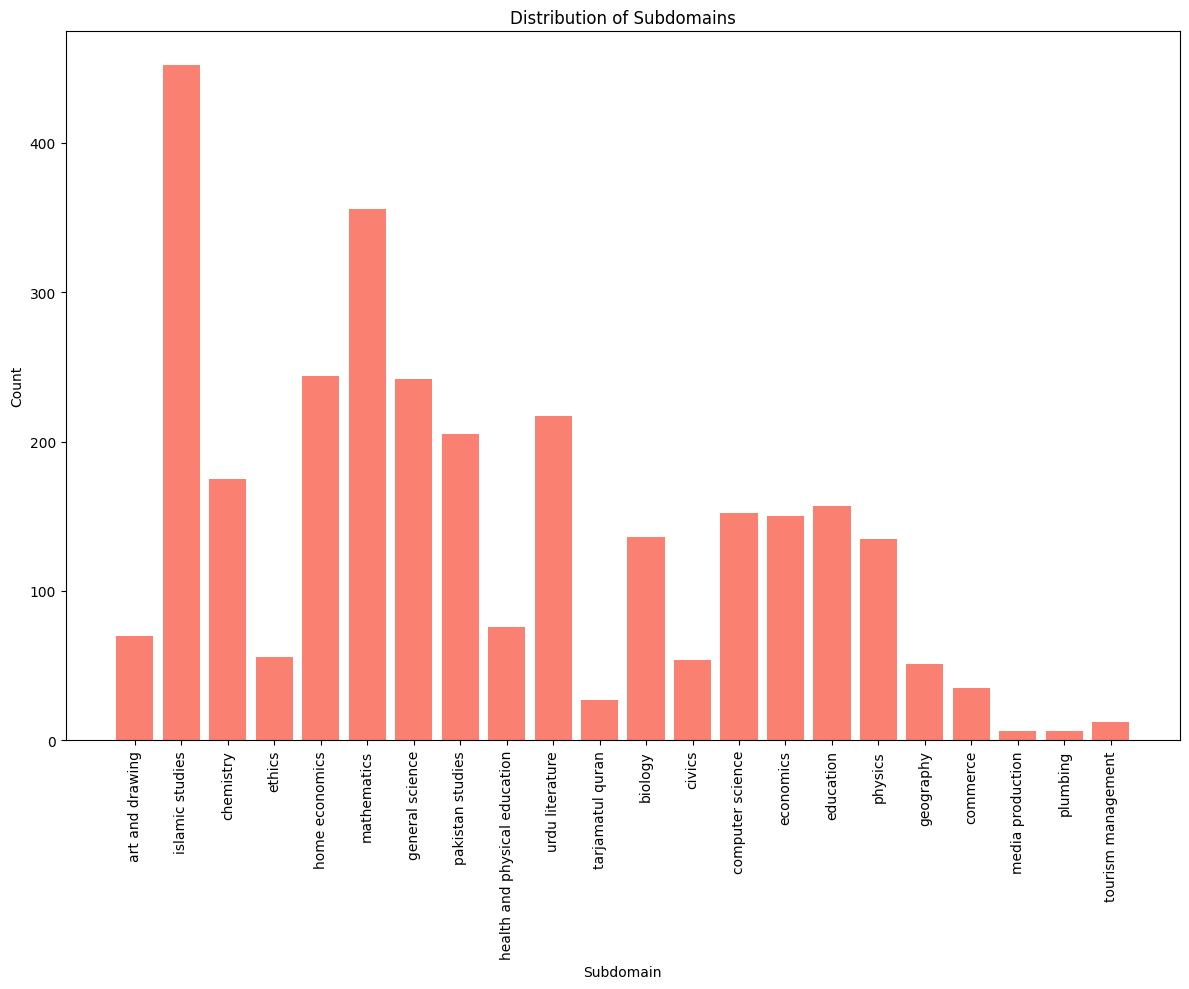

In [16]:
subdomains = [item['subdomain'] for item in data]
subdomain_counts = Counter(subdomains)

# rotate x-axis labels for better readability to 90 degrees
plt.figure(figsize=(12, 10))
plt.bar(subdomain_counts.keys(), subdomain_counts.values(), color='salmon')
plt.title('Distribution of Subdomains')
plt.xlabel('Subdomain')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [17]:
# find unique subdomains in the data
unique_sub_domains = set()
for item in data:
    unique_sub_domains.add(item['subdomain'])
len(unique_sub_domains)

22

In [18]:
data[0]

{'question_number': 1,
 'question': 'آرٹ کی اقسام ہوتی ہیں۔',
 'options': {'A': 'چار', 'B': 'ایک', 'C': 'دو', 'D': 'تین'},
 'has_image': False,
 'image_bbox': None,
 'domain': 'STEM',
 'subdomain': 'art and drawing',
 'correct_option': None,
 'correct_index': None,
 'level': 'SSC-II',
 'page': 1,
 'source_url': '',
 'source_image': 'AMD 10th_page_0001.jpg',
 'folder': 'AMD 10th',
 'provider': 'gemini',
 'model': 'gemini-3-flash-preview'}

In [19]:
with open('3-final/mcqs_without_answers.json', 'r') as f:
    new = json.load(f)

In [20]:
# find the value of question key of old in the question key of new and when match is found get the value of source key and store it in source key of data
for item in data:
    for new_item in new:
        if item['question'] == new_item['question']:
            item['source'] = new_item['source']
            break

In [21]:
# find unique value of key domain
domains = set([item['source'] for item in data])
domains

{'BISE Multan 2025', 'FBISE', 'Ustad 360'}

In [22]:
# where the source key is Ustad 360 replace it with BISE Multan 2025
for item in data:
    if item['source'] == 'Ustad 360':
        item['source'] = 'BISE Multan 2025'

In [23]:
# find unique value of key domain
domains = set([item['source'] for item in data])
domains

{'BISE Multan 2025', 'FBISE'}

In [25]:
# find unique values of key domain
unique_domains = set()
for item in data:
    unique_domains.add(item['domain'])
unique_domains

{'STEM'}

In [35]:
with open('2-processed/stem.json', 'w') as f:
    json.dump(data, f, ensure_ascii=False, indent=4)